# Healthcare Access and Socioeconomic Disparities in Michigan ZIP Codes (1990–2021)
**SI 305 | Final Project | Mo Pofahl**

## Research Questions

**RQ1:** How has physician density changed across Michigan ZIP codes between 1990 and 2021, and does it differ by income level?

**RQ2:** Which demographic characteristics, specifically poverty rate, median family income, disadvantage index, proportion non-Hispanic Black, and proportion Hispanic, are most strongly associated with low physician density across Michigan ZCTAs in 2021?

---
## Setup

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats



---
## Data Loading

### Healthcare Data
NaNDA Health Care Services by ZCTA (ICPSR). Loaded for 1990–2021

In [2]:
# Loading healthcare data in, using only columns ZCTA20, year, den_allphysicians, count_allphysicians
healthcare = pd.read_csv(
    "healthcare_data/nanda_healthcare_1990-2021_CSVs/nanda_healthcare_ZCTA20_1990-2021_01P.csv",
    usecols=["zcta20", "year", "den_allphysicians", "count_allphysicians"],
    dtype={"zcta20": str}
)

# filter to Michigan ZCTAs (beginning with 48 or 49)
healthcare = healthcare[healthcare["zcta20"].str.startswith(("48", "49"))]

# full 1990-2021 range, income quartile classification comes from the 2016-2020 socioeconomic snapshot,
# which is used as a fixed label for each ZCTA, so pre-2008 data is still valid for the longitudinal trend
healthcare = healthcare[(healthcare["year"] >= 1990) & (healthcare["year"] <= 2021)]

print(healthcare.shape)

(31744, 4)


### Socioeconomic Data
NaNDA Socioeconomic Status and Demographic Characteristics of ZCTAs, 2016–2020 snapshot (ICPSR 38528, DS0005)

In [3]:
# Loading the socioeconomic snapshot, from a TSV file
# Only loading columns ZCTA20, MEDFAMINC16_20, PPOV16_20, DISADVANTAGE16_20,
# PNHBLACK16_20, PHISPANIC16_20
socioeconomic = pd.read_csv(
    "Socioeconomic-data/ICPSR_38528/DS0005/38528-0005-Data.tsv",
    sep="\t",
    usecols=["ZCTA20", "MEDFAMINC16_20", "PPOV16_20", "DISADVANTAGE16_20", "PNHBLACK16_20", "PHISPANIC16_20"],
    dtype={"ZCTA20": str}
)

# filtering to Michigan ZCTAs (begin with 48 or 49)
socioeconomic = socioeconomic[socioeconomic["ZCTA20"].str.startswith(("48", "49"))]


# Converting the columns to numeric values in pandas
cols = ["MEDFAMINC16_20", "PPOV16_20", "DISADVANTAGE16_20", "PNHBLACK16_20", "PHISPANIC16_20"]
socioeconomic[cols] = socioeconomic[cols].apply(pd.to_numeric, errors="coerce")


print(socioeconomic.shape)
socioeconomic.head()

(987, 6)


,ZCTA20,PHISPANIC16_20,PNHBLACK16_20,PPOV16_20,DISADVANTAGE16_20,MEDFAMINC16_20
15592,48001,0.016469,0.001008,0.112617,0.151839,72882.0
15593,48002,0.009672,0.000000,0.042866,0.072762,78702.0
15594,48003,0.055851,0.000000,0.082234,0.099778,92875.0
15595,48005,0.010698,0.002539,0.044995,0.062947,98281.0
15596,48006,0.008668,0.000743,0.193267,0.178384,77000.0


---
## Data Cleaning and Preparation

### Inspecting and Handling missing values, documenting rows dropped and why


#### Healthcare dataset cleaning

In [4]:
#Counting null values in healthcare columns
display(healthcare.isnull().sum())
display(healthcare.shape)

zcta20                   0
year                     0
count_allphysicians      0
den_allphysicians      108
dtype: int64

(31744, 4)

In [5]:
#Dropping rows missing den_allphysicians (108 rows, <0.35% of the data): unusuable
healthcare = healthcare.dropna(subset=["den_allphysicians"])
display(healthcare.shape)


(31636, 4)

#### socioeconomic cleaning

In [6]:
#Checking null counts
socioeconomic.isnull().sum()

# drop rows missing MEDFAMINC16_20 (48 rows) — cannot be classified into income quartiles
socioeconomic = socioeconomic.dropna(subset=["MEDFAMINC16_20"])

print(socioeconomic.isnull().sum())


ZCTA20               0
PHISPANIC16_20       0
PNHBLACK16_20        0
PPOV16_20            0
DISADVANTAGE16_20    0
MEDFAMINC16_20       0
dtype: int64


### Merge Datasets
Joining the datasets, inner joined on zcta20 (geographical locator)

In [7]:
# merge healthcare and socioeconomic data on ZCTA20
socioeconomic = socioeconomic.rename(columns={"ZCTA20": "zcta20"})
michigan_data = pd.merge(healthcare, socioeconomic, on='zcta20', how='inner')
print(michigan_data.shape)
michigan_data.head()

(30048, 9)


,zcta20,year,count_allphysicians,den_allphysicians,PHISPANIC16_20,PNHBLACK16_20,PPOV16_20,DISADVANTAGE16_20,MEDFAMINC16_20
0,48001,1990,3,0.243543,0.016469,0.001008,0.112617,0.151839,72882.0
1,48001,1991,4,0.322907,0.016469,0.001008,0.112617,0.151839,72882.0
2,48001,1992,4,0.321111,0.016469,0.001008,0.112617,0.151839,72882.0
3,48001,1993,4,0.319334,0.016469,0.001008,0.112617,0.151839,72882.0
4,48001,1994,5,0.396971,0.016469,0.001008,0.112617,0.151839,72882.0


### Defining Income Quartiles
Classifying Michigan ZCTAs into four income quartiles using MEDFAMINC.

In [8]:
# assigning income quartile labels based on MEDFAMINC
michigan_data["income_quartile"] = pd.qcut(
    michigan_data['MEDFAMINC16_20'], q=4, labels=["Lowest Income", "Low-Middle", "High-Middle", "Highest Income"]
)
michigan_data["income_quartile"].value_counts()

income_quartile
Lowest Income     7520
Low-Middle        7520
High-Middle       7520
Highest Income    7488
Name: count, dtype: int64

---
## RQ1: Physician Density Trends by Income Quartile (1990–2021)

### Average Physician Density by Income Quartile and Year

In [9]:
# Grouping income quartile and year
# calculating average physician density per income quartile per year
rq1 = michigan_data.groupby(["income_quartile", "year"], observed=True)['den_allphysicians'].mean().reset_index()
rq1.columns = ['income_quartile', 'year', 'avg_physician_density']

### Plotting Average Physician Density per 10,000 residents by Income Quartile per year

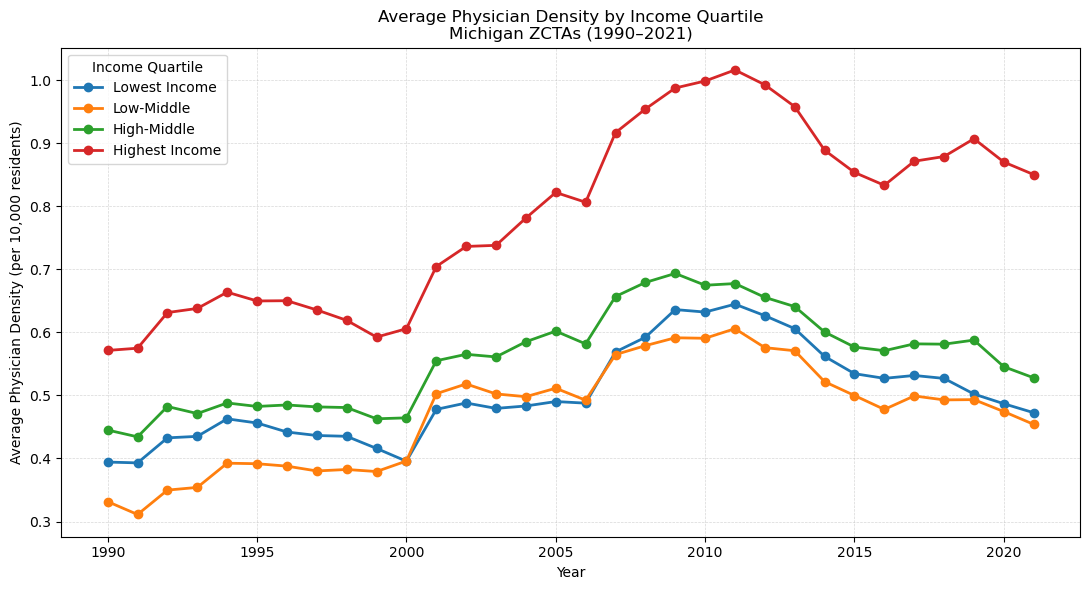

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

for quartile in ["Lowest Income", "Low-Middle", "High-Middle", "Highest Income"]:
    data = rq1[rq1["income_quartile"] == quartile]
    ax.plot(data["year"], data["avg_physician_density"], marker="o", linewidth=2, label=quartile)

ax.set_title("Average Physician Density by Income Quartile\nMichigan ZCTAs (1990–2021)")
ax.set_xlabel("Year")
ax.set_ylabel("Average Physician Density (per 10,000 residents)")
ax.legend(title="Income Quartile")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

### Visualization 1 Summary

Highest income ZIP codes had consistently higher physician density than all other groups across the entire 31-year period. All four groups rose together from around 2000 to 2011, then declined after 2011. The highest income group pulled further ahead during the 2000s and never came back down to the levels of the other three groups. By 2021, the gap between the highest and lowest income ZIP codes was larger than it was in 1990, suggesting the divide got worse over time rather than better.

### Robustness Checks

#### Alternative income grouping: DISADVANTAGE index
Re-running the analysis using the DISADVANTAGE composite index instead of MEDFAMINC quartiles to check whether results hold under a different definition of income.

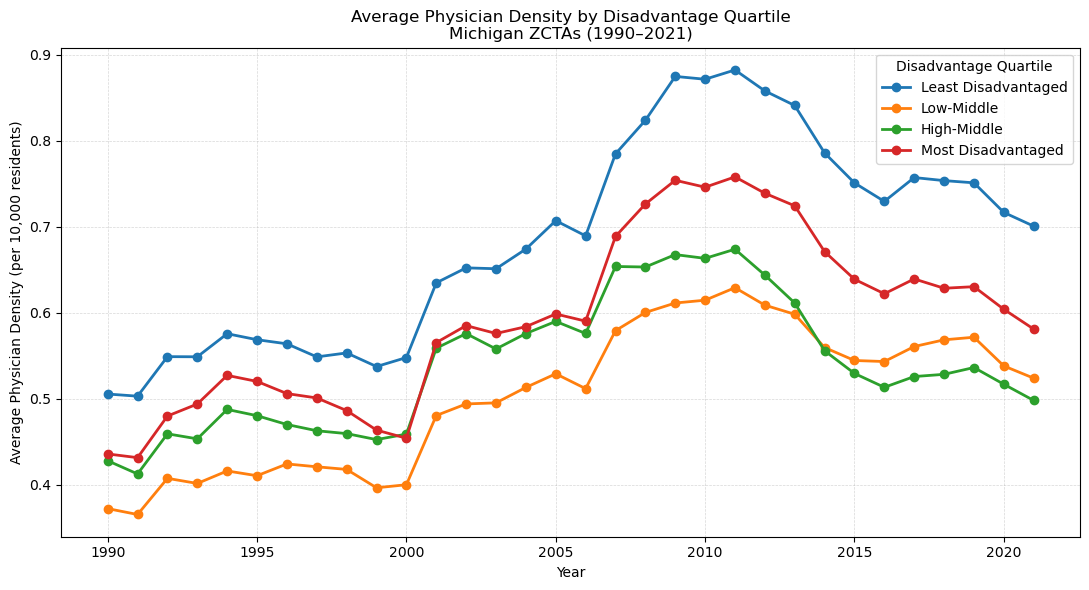

In [11]:
michigan_data["disadvantage_quartile"] = pd.qcut(
    michigan_data["DISADVANTAGE16_20"],
    q=4,
    labels=["Least Disadvantaged", "Low-Middle", "High-Middle", "Most Disadvantaged"]
)

rq1_robust1 = michigan_data.groupby(["disadvantage_quartile", "year"], observed=True)["den_allphysicians"].mean().reset_index()
rq1_robust1.columns = ["disadvantage_quartile", "year", "avg_physician_density"]

fig, ax = plt.subplots(figsize=(11, 6))

for quartile in ["Least Disadvantaged", "Low-Middle", "High-Middle", "Most Disadvantaged"]:
    data = rq1_robust1[rq1_robust1["disadvantage_quartile"] == quartile]
    ax.plot(data["year"], data["avg_physician_density"], marker="o", linewidth=2, label=quartile)

ax.set_title("Average Physician Density by Disadvantage Quartile\nMichigan ZCTAs (1990–2021)")
ax.set_xlabel("Year")
ax.set_ylabel("Average Physician Density (per 10,000 residents)")
ax.legend(title="Disadvantage Quartile")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

#### Alternative metric: count_allphysicians
Check whether using raw physician counts instead of density (den_allphysicians) changes the pattern.

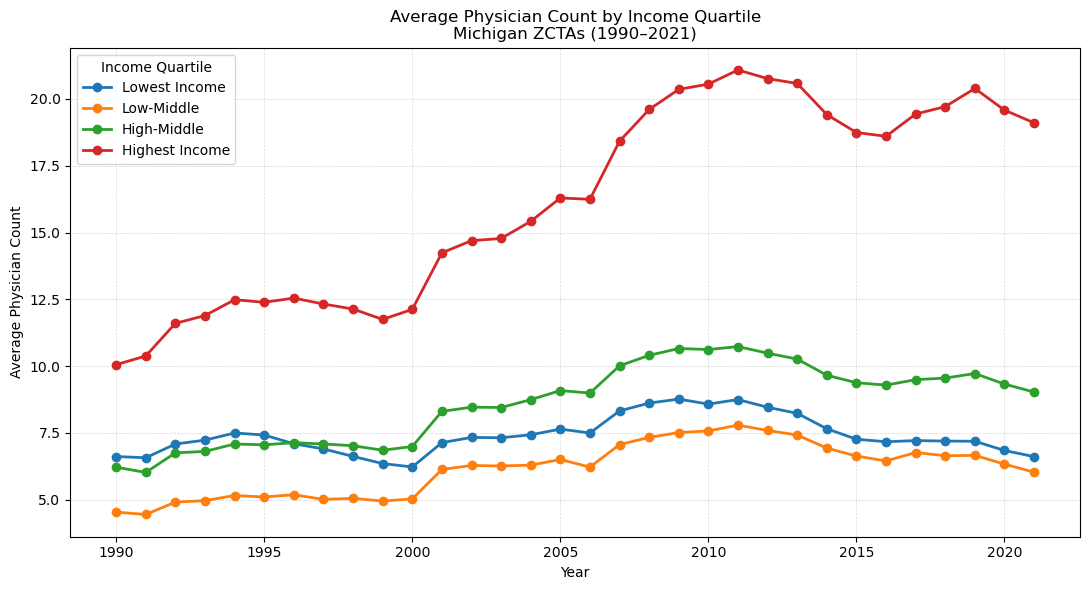

In [12]:
rq1_robust2 = michigan_data.groupby(["income_quartile", "year"], observed=True)["count_allphysicians"].mean().reset_index()
rq1_robust2.columns = ["income_quartile", "year", "avg_physician_count"]

fig, ax = plt.subplots(figsize=(11, 6))

for quartile in ["Lowest Income", "Low-Middle", "High-Middle", "Highest Income"]:
    data = rq1_robust2[rq1_robust2["income_quartile"] == quartile]
    ax.plot(data["year"], data["avg_physician_count"], marker="o", linewidth=2, label=quartile)

ax.set_title("Average Physician Count by Income Quartile\nMichigan ZCTAs (1990–2021)")
ax.set_xlabel("Year")
ax.set_ylabel("Average Physician Count")
ax.legend(title="Income Quartile")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

### Robustness Check Summary

**Check 1: DISADVANTAGE index instead of MEDFAMINC:** The same overall pattern held, the Least Disadvantaged ZCTAs consistently had the highest physician density and all groups rose together through the 2000s before declining after 2011. However, the ordering of the bottom three groups was less clear than in the main analysis, with the Most Disadvantaged group tracking closer to the middle rather than consistently at the bottom. The Least Disadvantaged group still pulled clearly ahead, which supports the main finding that more advantaged areas have better physician access regardless of how disadvantage is measured.

**Check 2: Raw physician count instead of density:** The same pattern held here as well. Highest Income ZCTAs still had the most physicians, all groups still declined over time, and the gap was still visible. This suggests the pattern is not simply a result of population size differences between ZIP codes, since the gap appears whether physician access is measured in raw numbers or adjusted for population size.

### Visualization #2: Gap in Average Physician Density: Highest vs. Lowest income ZCTA's 1990-2021

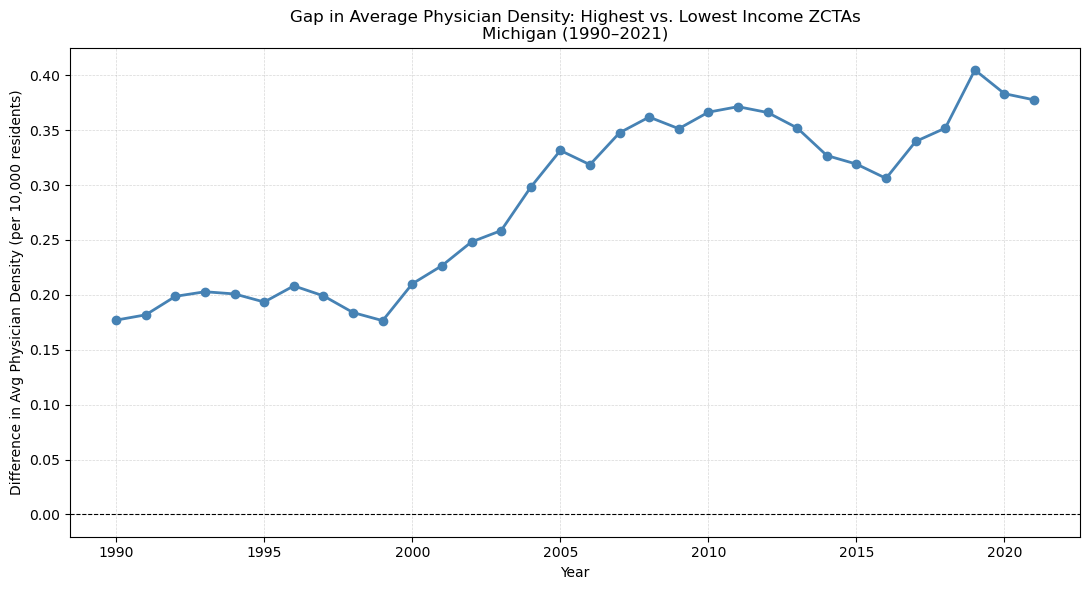

In [13]:
highest = rq1[rq1["income_quartile"] == "Highest Income"].set_index("year")["avg_physician_density"]
lowest = rq1[rq1["income_quartile"] == "Lowest Income"].set_index("year")["avg_physician_density"]
gap = highest - lowest

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(gap.index, gap.values, marker="o", linewidth=2, color="steelblue")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Gap in Average Physician Density: Highest vs. Lowest Income ZCTAs\nMichigan (1990–2021)")
ax.set_xlabel("Year")
ax.set_ylabel("Difference in Avg Physician Density (per 10,000 residents)")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

### Visualization 2 Summary

The gap between the highest and lowest income ZIP codes never fully closed over the 31 years. It narrowed somewhat around 2013–2016, then widened again after 2016 and peaked around 2019. The gap remained throughout the entire period with no lasting progress toward closing it.

---
## RQ2: Demographic Predictors of Low Physician Density (2021)

**Predictor Key:**
| Variable | Description |
|---|---|
| MEDFAMINC16_20 | Median family income |
| PPOV16_20 | Poverty rate |
| DISADVANTAGE16_20 | Composite disadvantage index |
| PNHBLACK16_20 | Proportion non-Hispanic Black |
| PHISPANIC16_20 | Proportion Hispanic |


In [14]:
# filtering to 2021 only, since RQ2 is a cross-sectional analysis of a single year, not longitudinal
data_2021 = michigan_data[michigan_data['year'] == 2021]

In [15]:
# correlation analysis: den_allphysicians vs PPOV, MEDFAMINC, DISADVANTAGE, PNHBLACK, PHISPANIC
predictors = ["MEDFAMINC16_20", "PPOV16_20", "DISADVANTAGE16_20", "PNHBLACK16_20", "PHISPANIC16_20"]

In [16]:
# loop through each predictor, compute Pearson r and p-value against physician density
# mask excludes rows where the predictor is null so both arrays stay aligned
results = []
for predictor in predictors:
    mask = data_2021[predictor].notna()
    r, p = stats.pearsonr(data_2021.loc[mask, predictor], data_2021.loc[mask, "den_allphysicians"])
    results.append({"predictor": predictor, "correlation": r, "p_value": p})

In [17]:
# build results table, add absolute correlation for sorting, sort by strength descending
rq2 = pd.DataFrame(results)
rq2['abs_correlation'] = rq2['correlation'].abs()
rq2 = rq2.sort_values('abs_correlation', ascending=False)
rq2

,predictor,correlation,p_value,abs_correlation
0,MEDFAMINC16_20,0.228740,1.300737e-12,0.228740
3,PNHBLACK16_20,0.174130,7.880518e-08,0.174130
2,DISADVANTAGE16_20,-0.044948,1.687574e-01,0.044948
4,PHISPANIC16_20,0.028915,3.761333e-01,0.028915
1,PPOV16_20,0.000427,9.895827e-01,0.000427


### Visualization 1: Correlation Strength by Predictor

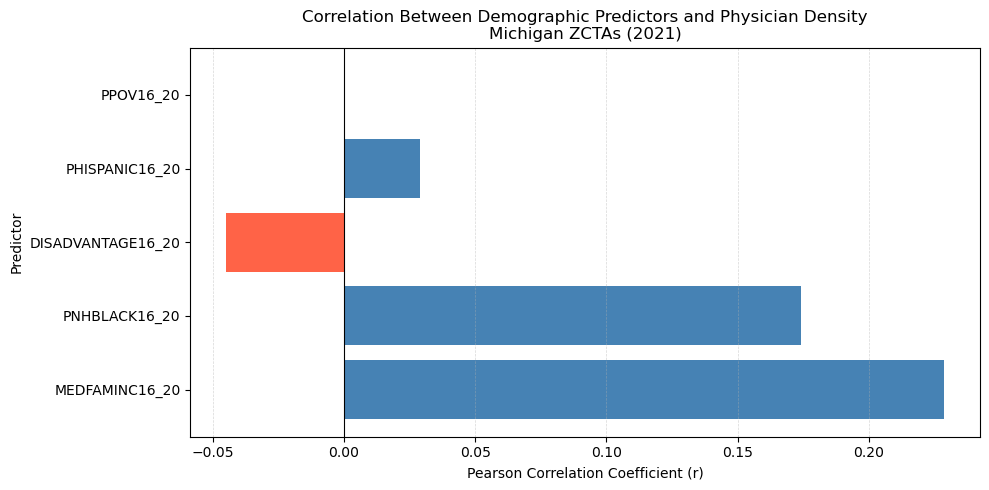

In [18]:
colors = ["steelblue" if c > 0 else "tomato" for c in rq2["correlation"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rq2["predictor"], rq2["correlation"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation Between Demographic Predictors and Physician Density\nMichigan ZCTAs (2021)")
ax.set_xlabel("Pearson Correlation Coefficient (r)")
ax.set_ylabel("Predictor")
ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

### Visualization 1 Summary

Median family income (MEDFAMINC) had the strongest correlation with physician density (r = 0.23, p < 0.001), and it was the only predictor that clearly stood out from the rest. PNHBLACK also reached significance (r = 0.17, p < 0.001), but its positive direction was not what I expected, because areas with higher proportions of Black residents actually had more physicians on average. Poverty rate (PPOV) had essentially zero correlation with physician density.

### Robustness Check: Multicollinearity check — correlation matrix among predictors

In [19]:
# correlation matrix among predictor variables
corr_matrix = data_2021[predictors].corr()
corr_matrix

,MEDFAMINC16_20,PPOV16_20,DISADVANTAGE16_20,PNHBLACK16_20,PHISPANIC16_20
MEDFAMINC16_20,1.000000,-0.615270,-0.759644,-0.241539,-0.100937
PPOV16_20,-0.615270,1.000000,0.917221,0.485364,0.217897
DISADVANTAGE16_20,-0.759644,0.917221,1.000000,0.525006,0.199073
PNHBLACK16_20,-0.241539,0.485364,0.525006,1.000000,0.102951
PHISPANIC16_20,-0.100937,0.217897,0.199073,0.102951,1.000000


#### Alternative year: 2018
Re-running the correlation analysis using 2018 data to check whether the ranking of predictors is stable across years.

In [20]:
data_2018 = michigan_data[michigan_data['year'] == 2018]

results_2018 = []
for predictor in predictors:
    mask = data_2018[predictor].notna()
    r, p = stats.pearsonr(data_2018.loc[mask, predictor], data_2018.loc[mask, "den_allphysicians"])
    results_2018.append({"predictor": predictor, "correlation": r, "p_value": p})

rq2_2018 = pd.DataFrame(results_2018)
rq2_2018['abs_correlation'] = rq2_2018['correlation'].abs()
rq2_2018 = rq2_2018.sort_values('abs_correlation', ascending=False)
rq2_2018

,predictor,correlation,p_value,abs_correlation
0,MEDFAMINC16_20,0.208305,1.152628e-10,0.208305
3,PNHBLACK16_20,0.179141,3.259772e-08,0.179141
2,DISADVANTAGE16_20,-0.042292,1.953850e-01,0.042292
4,PHISPANIC16_20,0.023575,4.705677e-01,0.023575
1,PPOV16_20,-0.001167,9.715025e-01,0.001167


### Robustness Check Summary

**Multicollinearity check:** PPOV and DISADVANTAGE are correlated at r = 0.92 with each other, which is why neither one reached statistical significance in the main analysis. MEDFAMINC has moderate correlations with both (r = -0.62 with PPOV and r = -0.76 with DISADVANTAGE), so its capturing something distinct. This explains why MEDFAMINC came out clearly on top while PPOV showed essentially zero correlation with physician density despite measuring a similar thing.

**Alternative year (2018):** The predictor ranking was identical: MEDFAMINC was still the strongest (r = 0.21), PNHBLACK was still second (r = 0.18), and PPOV was still near zero. The fact that the same pattern holds two years earlier gives me confidence the 2021 finding is not a one-year anomaly.

### Visualization 2: Median Family Income vs. Physician Density

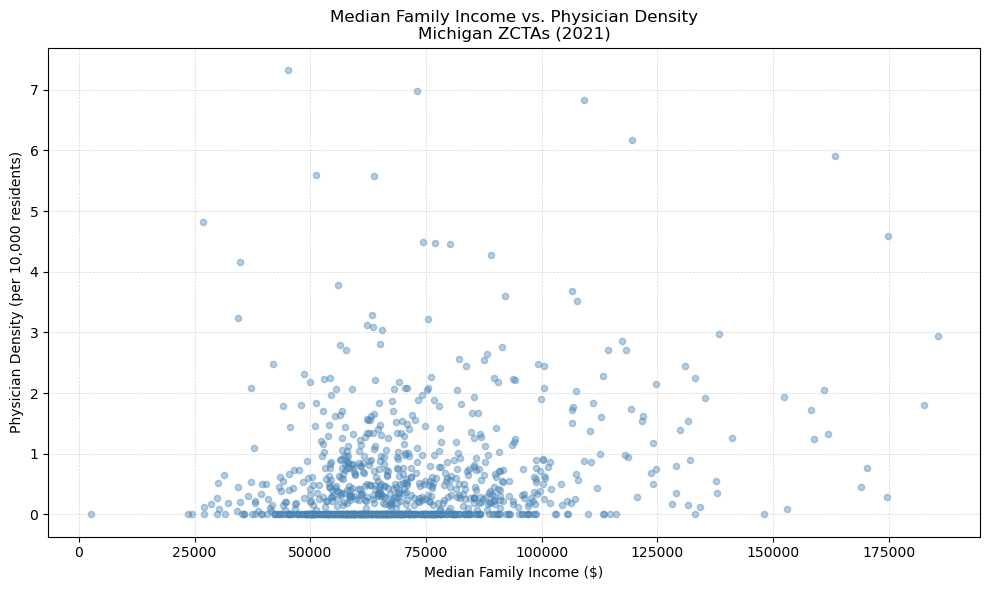

In [21]:
mask = data_2021["MEDFAMINC16_20"].notna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    data_2021.loc[mask, "MEDFAMINC16_20"],
    data_2021.loc[mask, "den_allphysicians"],
    alpha=0.4, s=20, color="steelblue"
)
ax.set_title("Median Family Income vs. Physician Density\nMichigan ZCTAs (2021)")
ax.set_xlabel("Median Family Income ($)")
ax.set_ylabel("Physician Density (per 10,000 residents)")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

### Visualization 2 Summary

There is a weak but visible positive trend, ZIP codes with higher median family income tended to have higher physician density. The scatter plot also shows a lot of spread, which reflects that income alone does not fully determine physician access and that other factors like urban vs. rural location, location of large hospital systems, etc. also play a role.  Most low-income ZIP codes are concentrated in the lower-left of the plot with both low income and low physician density.